<h2 style="color: #ff007f; font-size: 26px; text-align: center; margin-top: 20px; margin-bottom: 5px; font-family: 'Segoe UI', sans-serif; font-weight: 600;">EBS Spectrum </h2>
<p style="color: #ff007f; text-align: center; margin-top: 0; margin-bottom: 25px; font-size: 14px; font-weight: bold; text-transform: uppercase; letter-spacing: 1px;">José Sousa-Brito</p>


To run this script on a new experimental run, update the input files and channel boundaries at the top of the file:

### 1. Target File Paths

Provide absolute system paths for the element matrix file and the matching experimental evaluation file:

- **CH_MIN & CH_MAX (150 - 550):** Sets the active channel range filter mask to restrict data processing window boundaries.

```python
PATH_X = r'C:\Users\joseb\Desktop\...\671x0101.dat'     # Matrix file containing individual elements
PATH_EXP = r'C:\Users\joseb\Desktop\...\671f0101.dat'   # File containing raw data and global fit
```


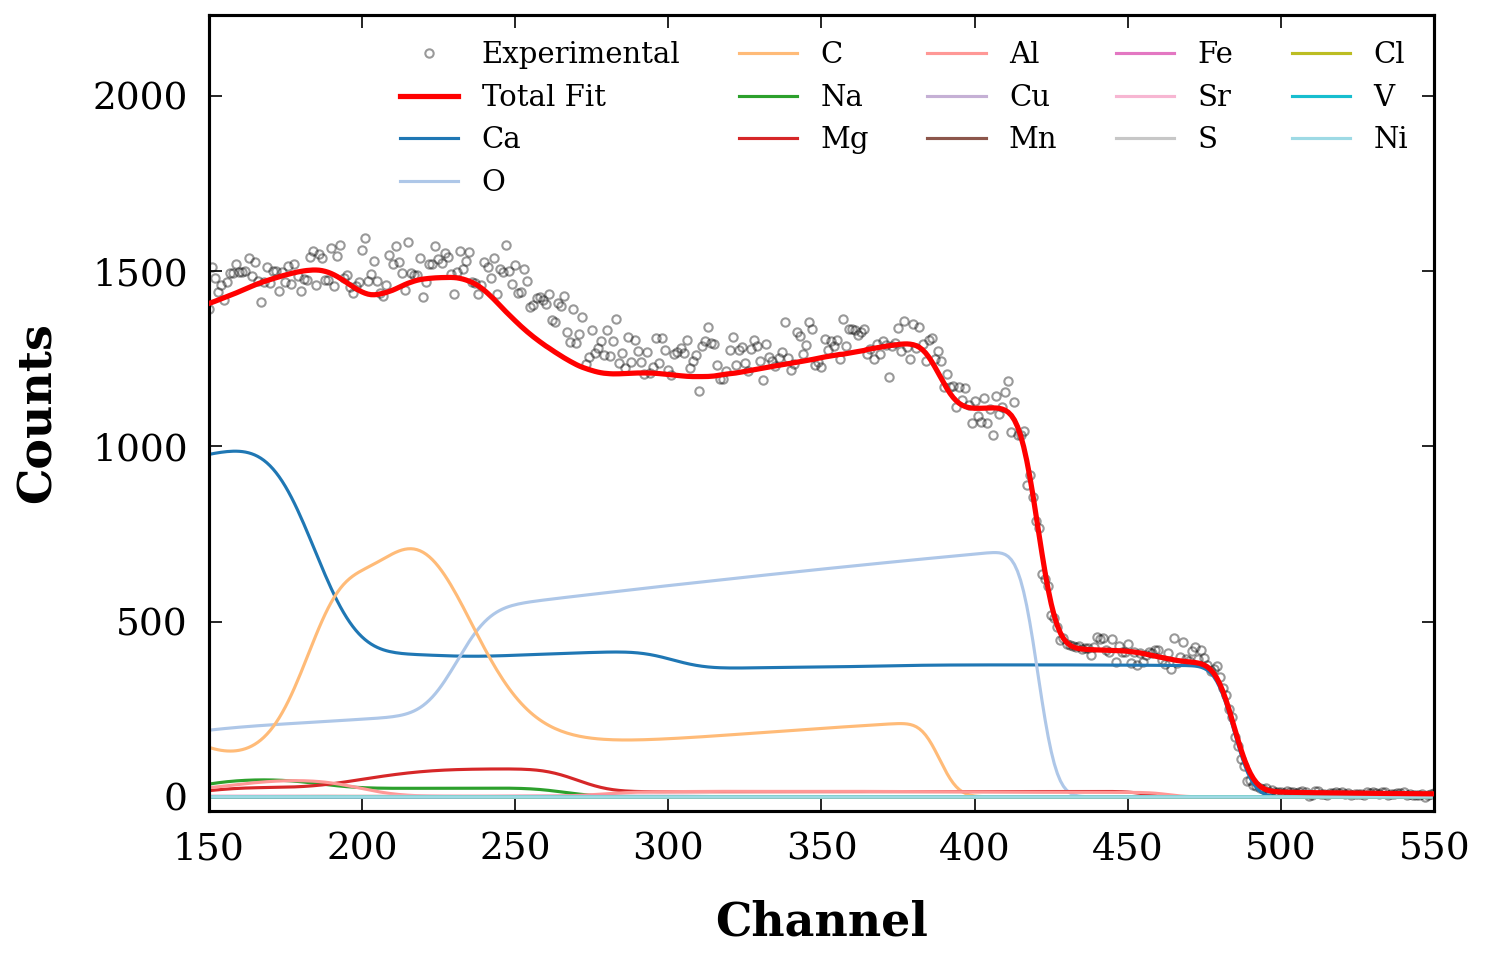

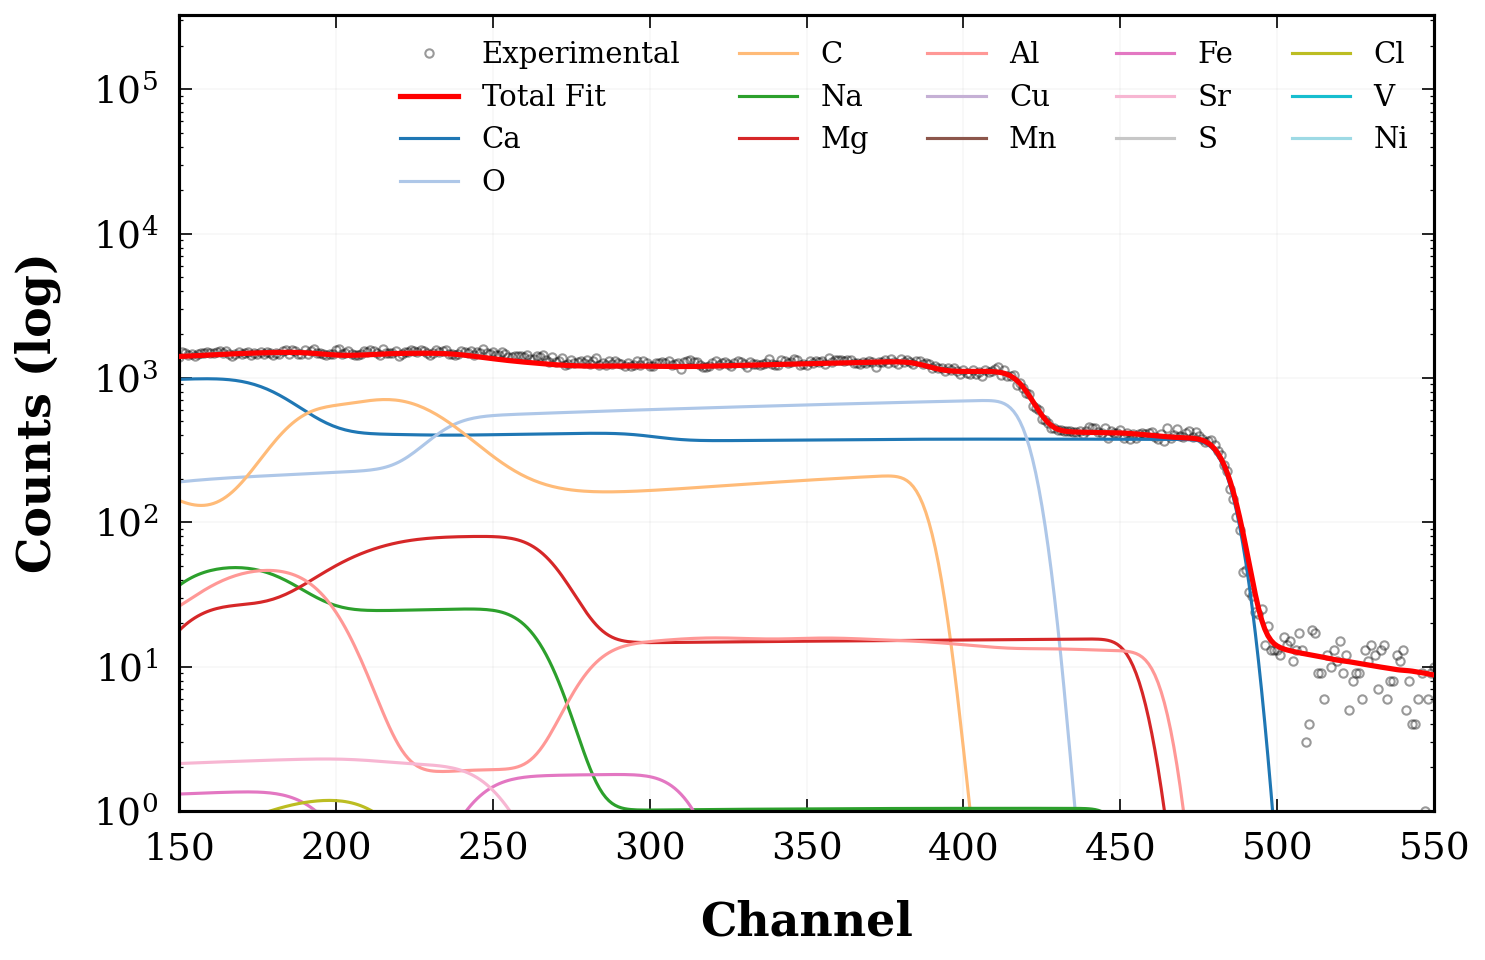

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

CH_MIN = 150
CH_MAX = 550
PATH_X = r'C:\Users\joseb\Desktop\Analise_Jose\Espectros_EBS\1965 keV\Foraminiferos\671131\671x0101.dat'
PATH_EXP = r'C:\Users\joseb\Desktop\Analise_Jose\Espectros_EBS\1965 keV\Foraminiferos\671131\671f0101.dat'


plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 1.5,
    "figure.dpi": 150,        
    "savefig.dpi": 600,       
    "xtick.direction": 'in',
    "ytick.direction": 'in',
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.top": True,
    "ytick.right": True,
    "xtick.labelsize": 18,          
    "ytick.labelsize": 18,          
})

with open(PATH_X, 'r', encoding='latin-1') as f:
    lines = f.readlines()
    element_names = lines[6].strip().split()

data_x = np.genfromtxt(PATH_X, skip_header=8)
data_f = np.genfromtxt(PATH_EXP, skip_header=6)

min_size = min(len(data_x), len(data_f))
channels = data_x[:min_size, 0]
exp_data = data_f[:min_size, 1]
fit_total = data_f[:min_size, 2]
data_x_clean = data_x[:min_size, :]

mask = (channels >= CH_MIN) & (channels <= CH_MAX)

def gerar_espectro(is_log=False):
    fig, ax = plt.subplots(figsize=(10, 6.5))
    
    ax.tick_params(axis='both', which='major', pad=10)
    
    if is_log:
        ax.set_yscale('log')
        mode = "Log"
        ax.set_ylabel('Counts (log)', fontweight='bold', fontsize=22, labelpad=15)
    else:
        mode = "Linear"
        ax.set_ylabel('Counts', fontweight='bold', fontsize=22, labelpad=15)

    ax.plot(channels[mask], exp_data[mask], 'ko', mfc='none', ms=4,    
            label='Experimental', alpha=0.4, markeredgewidth=1)

    ax.plot(channels[mask], fit_total[mask], color='red', lw=2.5,    
            label='Total Fit', zorder=20)

    colors = plt.cm.tab20(np.linspace(0, 1, len(element_names)))
    for i, (name, color) in enumerate(zip(element_names, colors)):
        col_index = i + 1 
        ax.plot(channels[mask], data_x_clean[mask, col_index], '-',    
                color=color, lw=1.5, label=name)

    ax.set_xlabel('Channel', fontweight='bold', fontsize=22, labelpad=15)
    ax.set_xlim(CH_MIN, CH_MAX)
    
    if is_log:
        ax.set_ylim(1, np.max(exp_data[mask]) * 205)
        ax.grid(True, which="major", ls="-", alpha=0.1)
    else:
        ax.set_ylim(-40, np.max(exp_data[mask]) * 1.4)

    ax.legend(loc='upper right', frameon=False, fontsize=14, ncol=5)
    
    plt.tight_layout()
    

    for ext in ['pdf']:
        plt.savefig(f'EBS_{mode}_Report.{ext}', bbox_inches='tight')
    
    plt.show()

gerar_espectro(is_log=False)
gerar_espectro(is_log=True)

<h2 style="color: #ff007f; font-size: 26px; text-align: center; margin-top: 20px; margin-bottom: 5px; font-family: 'Segoe UI', sans-serif; font-weight: 600;">Elemental Depth Profile Visualizer</h2>
<p style="color: #ff007f; text-align: center; margin-top: 0; margin-bottom: 25px; font-size: 14px; font-weight: bold; text-transform: uppercase; letter-spacing: 1px;">José Sousa-Brito</p>


To run this script on a new simulation file, update the source parameters and scaling constraints at the top of the file:

### 1. Target File Path

Provide the absolute path to your simulation output file. The script expects standard `.prf` text matrix layouts:

XLIM_MAX (105000): Restricts the maximum depth boundary window to focus on high-interest initial structural layer transitions. Set to None to display the entire parsed depth profile.

```python
PATH_PRF = r'C:\Users\joseb\Desktop\...\ndf.prf'
```

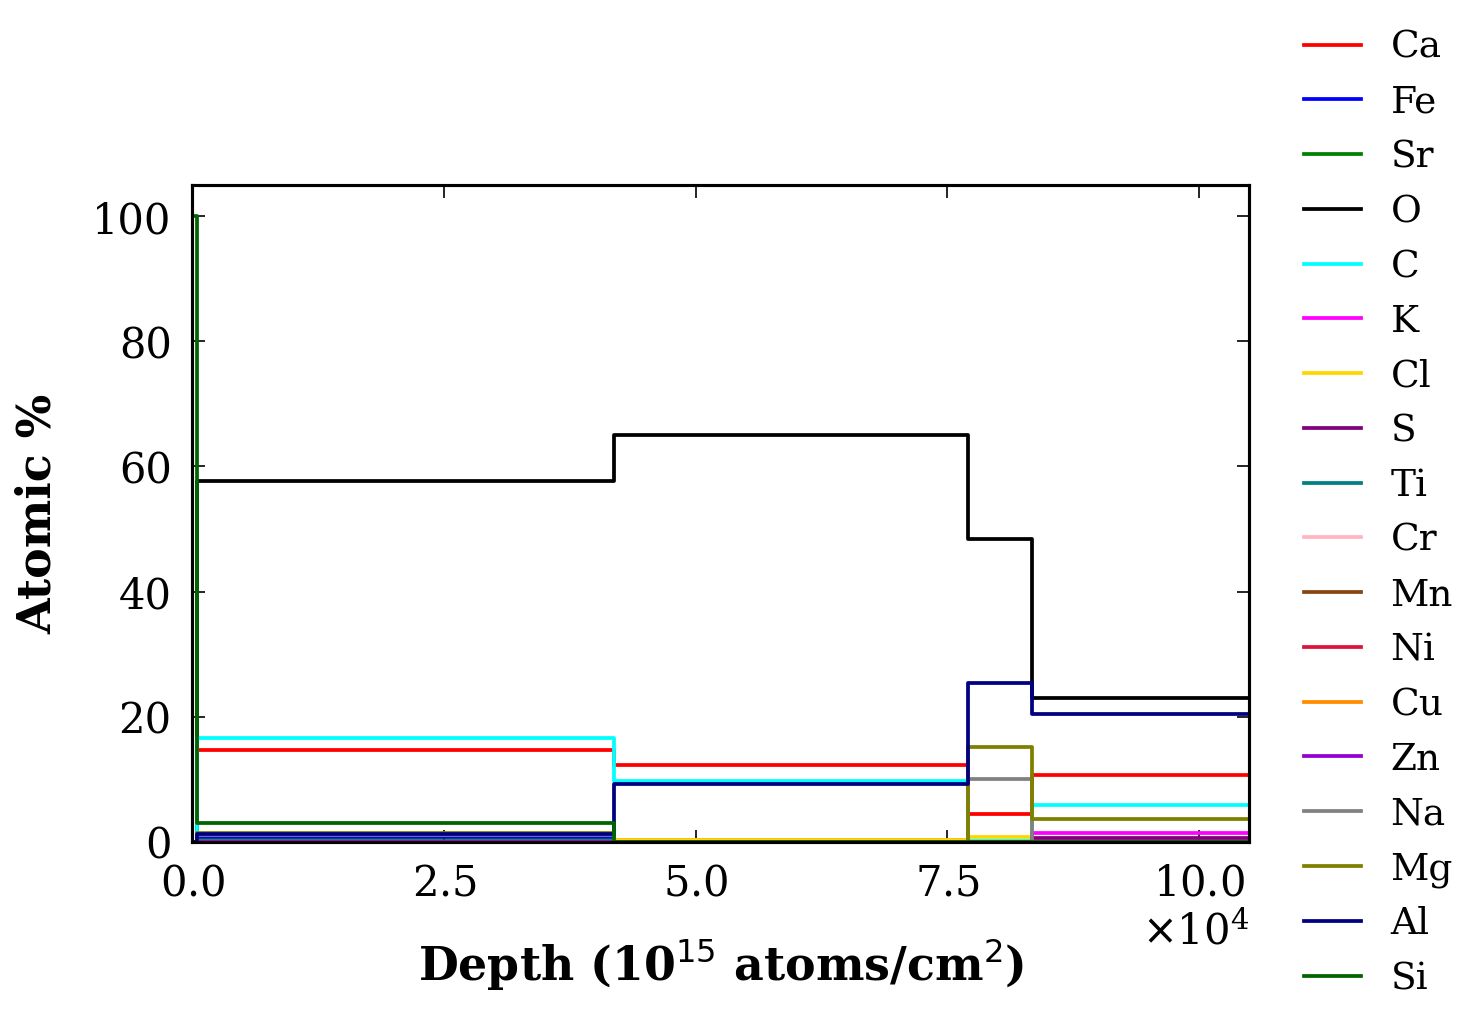

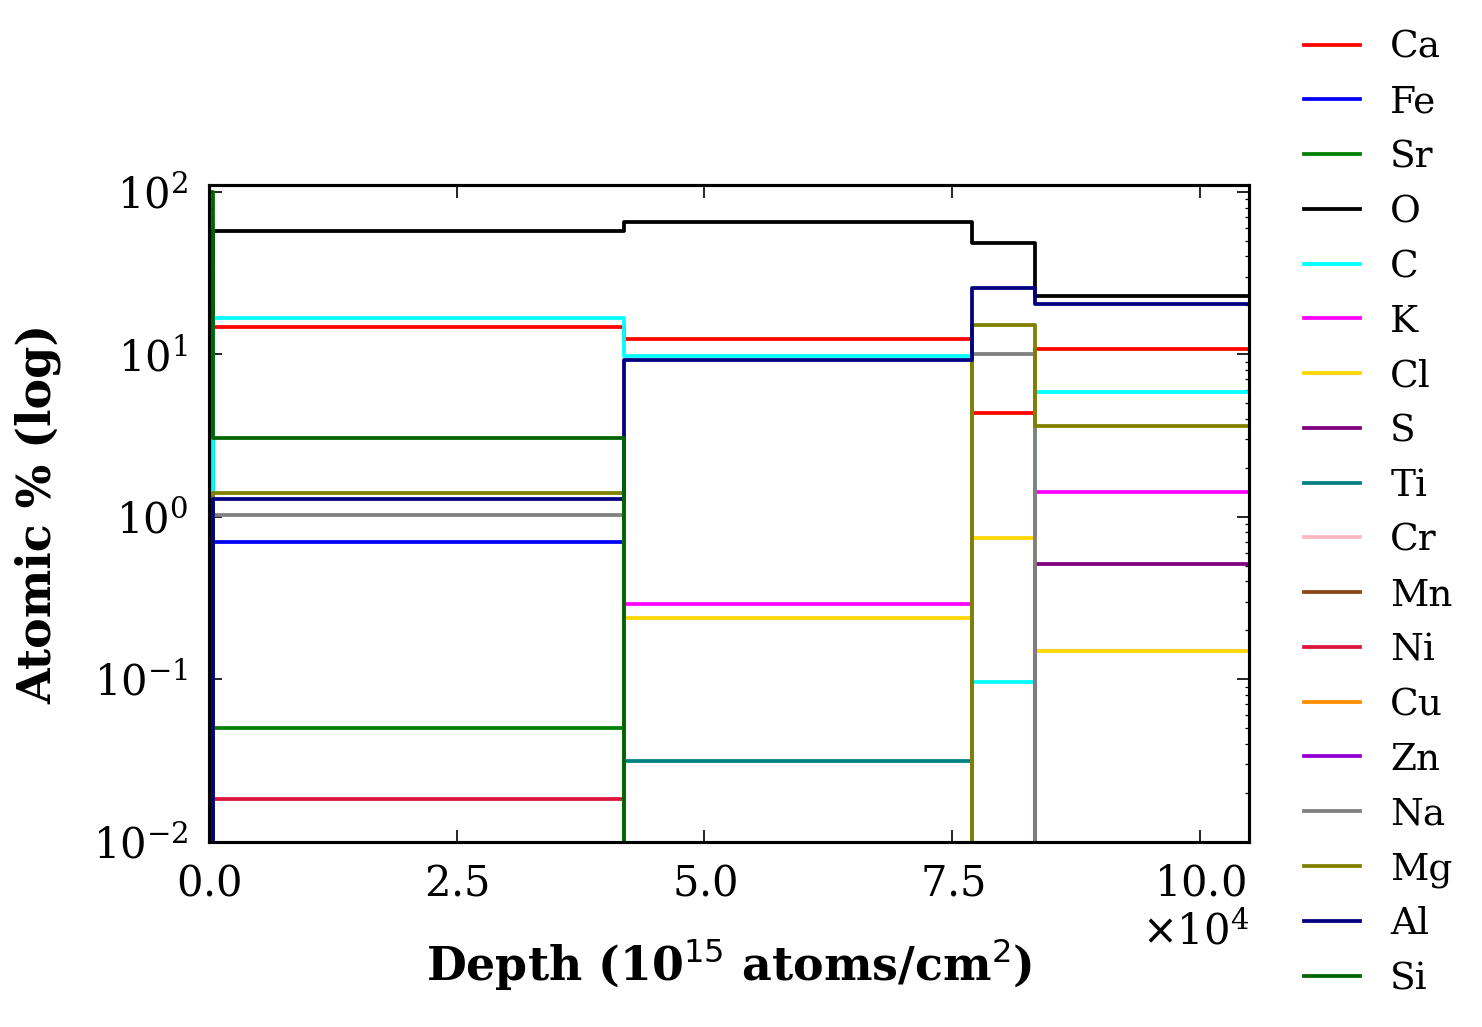

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter, MultipleLocator

PATH_PRF = r'C:\Users\joseb\Desktop\Analise_Jose\Espectros_EBS\1965 keV\Foraminiferos\671129\ndf.prf'
XLIM_MAX = 105000

plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "xtick.direction": 'in',
    "ytick.direction": 'in',
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.top": True,
    "ytick.right": True,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

with open(PATH_PRF, 'r', encoding='latin-1') as f:
    lines = [l for l in f.readlines() if l.strip() != '']

n_layers = int(lines[0].strip())
data_lines = lines[1:1 + n_layers]
header_line = lines[1 + n_layers].strip()

header_cols = header_line.split()
element_names = [
    c for c in header_cols
    if c.lower() != 't'
    and not any(ch.isdigit() for ch in c)
    and '(' not in c and ')' not in c
]

data = np.array([[float(v) for v in l.split()] for l in data_lines])
thickness = data[:, 0]
comp = data[:, 1:]

assert comp.shape[1] == len(element_names), \
    "Column mismatch between data and parsed headers."

depth_edges = np.concatenate(([0.0], np.cumsum(thickness)))

FIXED_COLORS = {
    'Ca': 'red',
    'Fe': 'blue',
    'Sr': 'green',
    'O':  'black',
    'C':  'cyan',
    'K':  'magenta',
    'Cl': 'gold',
    'S':  'purple',
    'Ti': 'teal',
    'Cr': 'lightpink',
    'Mn': 'saddlebrown',
    'Ni': 'crimson',
    'Cu': 'darkorange',
    'Zn': 'darkviolet',
    'Na': 'gray',
    'Mg': 'olive',
    'Al': 'navy',
    'Si': 'darkgreen',
}

extra_colors = plt.cm.tab20(np.linspace(0, 1, len(element_names)))
colors = [FIXED_COLORS.get(name, extra_colors[i]) for i, name in enumerate(element_names)]


class FixedOrderFormatter(ScalarFormatter):
    def __init__(self, order_of_mag=4, **kwargs):
        self._order_of_mag = order_of_mag
        ScalarFormatter.__init__(self, useMathText=True, **kwargs)

    def _set_order_of_magnitude(self):
        self.orderOfMagnitude = self._order_of_mag


def generate_profile(is_log=False):
    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.tick_params(axis='both', which='major', pad=10)

    for i, name in enumerate(element_names):
        y = comp[:, i]
        y_plot = np.append(y, y[-1])
        ax.step(depth_edges, y_plot, where='post',
                color=colors[i], lw=1.8, label=name)

    if is_log:
        ax.set_yscale('log')
        mode = "Log"
        ax.set_ylabel('Atomic % (log)', fontweight='bold', fontsize=22, labelpad=15)
        ax.set_ylim(1e-2, 110)
    else:
        mode = "Linear"
        ax.set_ylabel('Atomic %', fontweight='bold', fontsize=22, labelpad=15)
        ax.set_ylim(0, 105)

    ax.set_xlabel(r'Depth (10$^{15}$ atoms/cm$^2$)', fontweight='bold', fontsize=22, labelpad=15)
    xlim_max = XLIM_MAX if XLIM_MAX is not None else depth_edges[-1]
    ax.set_xlim(0, xlim_max)
    ax.xaxis.set_major_locator(MultipleLocator(25000))
    formatter = FixedOrderFormatter(order_of_mag=4)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)

    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
              frameon=False, fontsize=18, ncol=1, handlelength=1.5)

    plt.tight_layout()

    for ext in ['pdf']:
        plt.savefig(f'Depth_Profile_{mode}.{ext}', bbox_inches='tight')

    plt.show()


if __name__ == "__main__":
    generate_profile(is_log=False)
    generate_profile(is_log=True)